### Regression Exercise 
# Moneyball The NBA
---

### This HW is not easy. TRY IT YOURSELF FIRST! 
Then If you are able to complete it, [watch this lecture series on it](https://ocw.mit.edu/courses/15-071-the-analytics-edge-spring-2017/pages/linear-regression/playing-moneyball-in-the-nba-recitation/video-1-the-data/). 

In [68]:
# PANDAS IS FOR DATA WRANGLING
import pandas as pd
import numpy as np

# SEABORN IS A PLOTTING LIBRARY
import seaborn as sns

# MATPLOT LIB IS ALSO A PLOTTING LIBRARY
import matplotlib.pyplot as plt

# SKLEARN IS OUR MACHINE LEARNING PACKAGE
from sklearn.linear_model import LinearRegression

# IMPORT OUR RANDOM FOREST REGERSSOR
from sklearn.ensemble import RandomForestRegressor

# METRICS HELP US SCORE OUR MODEL
from sklearn import metrics

# HELP US SPLIT OUR DATA INTO TESTING A TRAINING
from sklearn.model_selection import train_test_split

!pip install statsmodels

# Good ol statsmodels
import statsmodels.api as sm

# Specific root mean squared error for stats models
from statsmodels.tools.eval_measures import rmse


from statsmodels.stats.outliers_influence import variance_inflation_factor


from statsmodels.api import qqplot

import CTPLIB as ctp



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip


ModuleNotFoundError: No module named 'CTPLIB'

# Remember our main steps motto _isbe_.
1. i - Inspect and explore data.
2. s - Select and engineer features.
3. b - Build and train model.
4. e - Evaluate model.

# STEP 1 (i): Inspect and explore data
1. Use `data/NBA_test.csv and data/NBA_train.csv`

In [ ]:
# READ IN THE DATA USING PANDAS 
df = pd.read_csv('/workspaces/ds-fall-2025-wed-M.E.P./Week-08-Regression/data/NBA_train.csv')


# DISPLAY THE FIRST 5 ROWS
df.head()

,SeasonEnd,Team,Playoffs,W,PTS,oppPTS,FG,FGA,2P,2PA,3P,3PA,FT,FTA,ORB,DRB,AST,STL,BLK,TOV
0,1980,Atlanta Hawks,1,50,8573,8334,3261,7027,3248,6952,13,75,2038,2645,1369,2406,1913,782,539,1495
1,1980,Boston Celtics,1,61,9303,8664,3617,7387,3455,6965,162,422,1907,2449,1227,2457,2198,809,308,1539
2,1980,Chicago Bulls,0,30,8813,9035,3362,6943,3292,6668,70,275,2019,2592,1115,2465,2152,704,392,1684
3,1980,Cleveland Cavaliers,0,37,9360,9332,3811,8041,3775,7854,36,187,1702,2205,1307,2381,2108,764,342,1370
4,1980,Denver Nuggets,0,30,8878,9240,3462,7470,3379,7215,83,255,1871,2539,1311,2524,2079,746,404,1533


```
SeasonEnd: Year season ended
Team: Name of team
Playoffs: If they made the playoffs. 1 == made to playoffs
W: Number of regular season in that season. 
PTS: Points scored in regular season. 
oppPTS: Opponent Points scored in regular season. 
FG: Field Goals made (total shots made == 2P and 3P combined)
FGA: Field Goals attempted (total shots attempted == 2P and 3P combined)
2P: two-pointers made
2PA: two-pointers attempted
3P: three-pointers made
3PA: three-pointers attempted
FT: Free-Throws made (not included in FG stat)
FTA: Free-Throws attempted (not included in FG stat)
ORB: Offensive Rebounds
DRB: Defensive Rebounds
AST: Assists made
STL: Steals 
BLK: Blocks 
TOV: Turnovers 
```

#### Inspect our data using `df.describe()` function.

In [ ]:
# Inspect our data using `df.describe()` function.
df.describe()

,SeasonEnd,Playoffs,W,PTS,oppPTS,FG,FGA,2P,2PA,3P,3PA,FT,FTA,ORB,DRB,AST,STL,BLK,TOV
count,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000
mean,1996.319760,0.574850,41.000000,8370.239521,8370.239521,3200.367665,6873.318563,2881.324551,5956.444311,319.043114,916.874251,1650.461078,2189.953293,1061.584431,2427.354491,1912.112575,668.364072,419.805988,1302.837126
std,9.243808,0.494662,12.740822,581.040114,587.543959,287.181266,401.027166,446.097941,830.596327,199.698941,523.982964,197.651728,244.491086,150.224519,130.671523,221.610925,93.393044,82.274913,153.973470
min,1980.000000,0.000000,11.000000,6901.000000,6909.000000,2565.000000,5972.000000,1981.000000,4153.000000,10.000000,75.000000,1189.000000,1475.000000,639.000000,2044.000000,1423.000000,455.000000,204.000000,931.000000
25%,1989.000000,0.000000,31.000000,7934.000000,7934.000000,2974.000000,6563.500000,2510.000000,5269.000000,131.500000,413.000000,1502.500000,2008.000000,953.500000,2346.500000,1735.000000,599.000000,359.000000,1192.000000
50%,1996.000000,1.000000,42.000000,8312.000000,8365.000000,3150.000000,6831.000000,2718.000000,5706.000000,329.000000,942.000000,1628.000000,2176.000000,1055.000000,2433.000000,1899.000000,658.000000,410.000000,1289.000000
75%,2005.000000,1.000000,50.500000,8784.500000,8768.500000,3434.500000,7157.000000,3296.000000,6753.500000,481.500000,1347.500000,1781.000000,2352.000000,1167.000000,2516.500000,2077.500000,729.000000,469.500000,1395.500000
max,2011.000000,1.000000,72.000000,10371.000000,10723.000000,3980.000000,8868.000000,3954.000000,7873.000000,841.000000,2284.000000,2388.000000,3051.000000,1520.000000,2753.000000,2575.000000,1053.000000,716.000000,1873.000000


#### Check for Nulls.

In [ ]:
# Check for Nulls.
df.isnull().sum()

SeasonEnd    0
Team         0
Playoffs     0
W            0
PTS          0
oppPTS       0
FG           0
FGA          0
2P           0
2PA          0
3P           0
3PA          0
FT           0
FTA          0
ORB          0
DRB          0
AST          0
STL          0
BLK          0
TOV          0
dtype: int64

#### Check for Duplicates

In [ ]:
# Check for Duplicates
df.duplicated().sum()

df[df.duplicated()]

,SeasonEnd,Team,Playoffs,W,PTS,oppPTS,FG,FGA,2P,2PA,3P,3PA,FT,FTA,ORB,DRB,AST,STL,BLK,TOV


#### Build a function that will INSPECT ANY DATAFRAME FOR YOU do this for you for any data frame you pass into it.

In [ ]:
def inspect_dataframe(input_df):
    print("Shape of DataFrame:", input_df.shape)
    print("\nColumn Names:\n", input_df.columns.tolist())
    print("\nNull Values:\n", input_df.isnull().sum())
    print("\nDuplicate Rows:", input_df.duplicated().sum())
    print("\nDescriptive Statistics:\n", input_df.describe())
    return "That gooood stuff."




#### Get a sense of how many wins it will take to make the playoffs. 
Make a scatter plot with x=Wins and the y=Team, and the hue=Playoffs

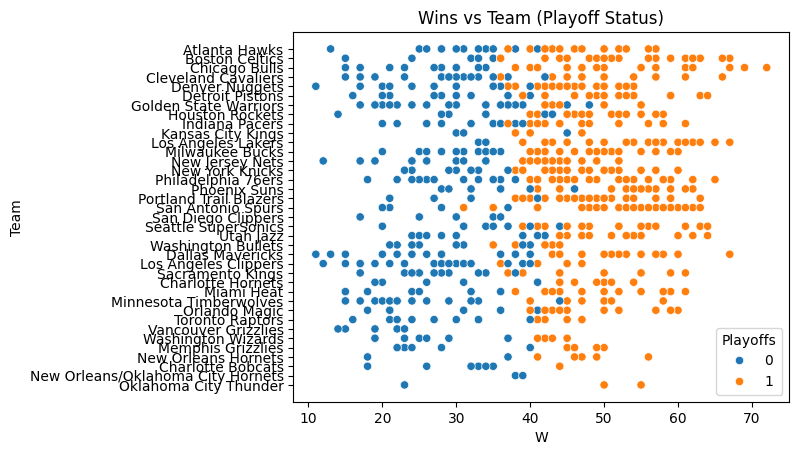

In [ ]:
df.columns

sns.scatterplot(data=df, x='W', y='Team', hue='Playoffs')

plt.title('Wins vs Team (Playoff Status)')
plt.xlabel('W')
plt.ylabel('Team')
plt.show()

#### Take a rough estimate, and now use that moving forward.  



In [ ]:
avg_wins_playoffs = df[df['Playoffs'] == 1]['W'].mean()
print("Average wins of playoff teams:", avg_wins_playoffs)

WINS_NEED_TO_MAKE_PLAYOFFS = round(avg_wins_playoffs)
print("Estimated wins needed to make playoffs:", WINS_NEED_TO_MAKE_PLAYOFFS)


Average wins of playoff teams: 49.74583333333333
Estimated wins needed to make playoffs: 50


---

# Now do moneyball but for the NBA. 

#### I would like you to do try and do this on your own first.  

It's not easy, but its fun af.  

There is a guided lecture on how to do this that I can send you, but I'd like for you to try and figure it out on your own first.  

If you are fully stuck, ask in slack how other people did it if that doesn't work (I highly encourage collorbration and learning from eachother.  I still consider that doing it on your own.)  

If that doesn't work, DM me and I will send you the lectures explaining how to do the whole thing.

In [ ]:
# Moneyball-for-NBA: team-season analysis pipeline
import pandas as pd
import numpy as np

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

# models & utils
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.impute import SimpleImputer

df_work = pd.read_csv("/workspaces/ds-fall-2025-wed-M.E.P./Week-08-Regression/data/NBA_train.csv")

print("Shape:", df_work.shape)
print("Columns:", df_work.columns.tolist())
print("Null counts:\n", df_work.isnull().sum())


# Drop rows missing the target W (can't predict without wins)
df_work = df_work[df_work['W'].notna()].copy()




Shape: (835, 20)
Columns: ['SeasonEnd', 'Team', 'Playoffs', 'W', 'PTS', 'oppPTS', 'FG', 'FGA', '2P', '2PA', '3P', '3PA', 'FT', 'FTA', 'ORB', 'DRB', 'AST', 'STL', 'BLK', 'TOV']
Null counts:
 SeasonEnd    0
Team         0
Playoffs     0
W            0
PTS          0
oppPTS       0
FG           0
FGA          0
2P           0
2PA          0
3P           0
3PA          0
FT           0
FTA          0
ORB          0
DRB          0
AST          0
STL          0
BLK          0
TOV          0
dtype: int64


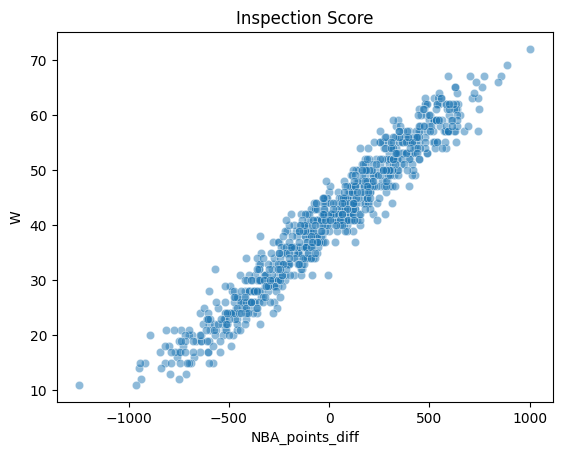

=== LINEAR REGRESSION: Predicting Wins from Points Difference ===

Intercept (β0): 41.0000
Coefficient (β1): 0.0326

Regression Equation: W = 41.0000 + 0.0326 * NBA_points_diff


In [ ]:
#FIRST MODEL - PREDICT WINS FROM POINTS DIFFERENCE 
# Calculate the point differential
df_work['NBA_points_diff'] = df_work['PTS'] - df_work['oppPTS']

# Check relationship
sns.scatterplot(data=df_work, x='NBA_points_diff', y='W', alpha=0.5)
plt.title('Inspection Score')
plt.show()


# Prepare data for regression
X = df_work[['NBA_points_diff']].values  # Independent variable (needs to be 2D for sklearn)
y = df_work['W'].values

# Fit the model
WinsReg = LinearRegression()
WinsReg.fit(X, y)


# Fit the linear regression model
WinsReg = LinearRegression()
WinsReg.fit(X, y)


# Display regression results
print("=== LINEAR REGRESSION: Predicting Wins from Points Difference ===\n")
print(f"Intercept (β0): {WinsReg.intercept_:.4f}")
print(f"Coefficient (β1): {WinsReg.coef_[0]:.4f}")
print(f"\nRegression Equation: W = {WinsReg.intercept_:.4f} + {WinsReg.coef_[0]:.4f} * NBA_points_diff")




In [ ]:
# Make predictions
y_pred = WinsReg.predict(X)

# Calculate metrics
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"\nModel Performance:")
print(f"  R² Score: {r2:.4f}")
print(f"  RMSE: {rmse:.4f}")






Model Performance:
  R² Score: 0.9423
  RMSE: 3.0575


In [ ]:
# SECOND MODEL - PREDICTING POINTS SCORED USING COMMON BASKETBALL STATS
# Prepare the data
X_points = df_work[['2PA', '3PA', 'FTA', 'AST', 'ORB', 'DRB', 'TOV', 'STL', 'BLK']].values
y_points = df_work['PTS'].values

print(f"X_points shape: {X_points.shape}")
print(f"y_points shape: {y_points.shape}")

# Fit the linear regression model
PointsReg = LinearRegression()
PointsReg.fit(X_points, y_points)

# Make predictions
y_points_pred = PointsReg.predict(X_points)

# Compute residuals
residuals_points = y_points - y_points_pred

SSE = np.sum(residuals_points**2)
print(f"SSE = Σ(residuals) = {SSE:.4f}\n")

# Calculate Root Mean Squared Error (RMSE)
RMSE = np.sqrt(np.mean(residuals_points**2))

print("=== ROOT MEAN SQUARED ERROR (RMSE) ===")
print(f"RMSE = √(Σ(residuals²)/n) = {RMSE:.4f}\n")

mean_points = df_work['PTS'].mean()

print("=== AVERAGE POINTS PER SEASON ===")
print(f"Mean Points: {mean_points:.2f}\n")

X_points shape: (835, 9)
y_points shape: (835,)
SSE = Σ(residuals) = 28394313.9948

=== ROOT MEAN SQUARED ERROR (RMSE) ===
RMSE = √(Σ(residuals²)/n) = 184.4049

=== AVERAGE POINTS PER SEASON ===
Mean Points: 8370.24



=== STATISTICAL SUMMARY OF POINTS REGRESSION ===

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.898
Method:                 Least Squares   F-statistic:                     817.3
Date:                Mon, 03 Nov 2025   Prob (F-statistic):               0.00
Time:                        02:04:05   Log-Likelihood:                -5541.1
No. Observations:                 835   AIC:                         1.110e+04
Df Residuals:                     825   BIC:                         1.115e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
co

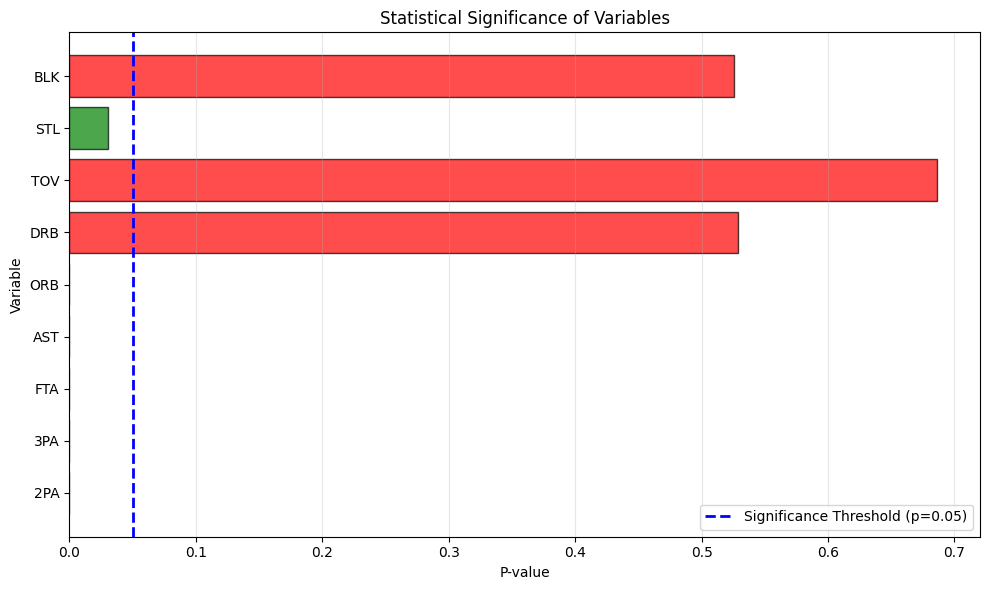


=== MODEL FIT STATISTICS ===
R-squared: 0.8992
Adjusted R-squared: 0.8981
F-statistic: 817.3217
Prob (F-statistic): 0.0000e+00
AIC: 11102.24
BIC: 11149.52


In [ ]:
import statsmodels.api as sm

# Use statsmodels for statistical summary
# Add constant (intercept) to the model
X_points_with_const = sm.add_constant(X_points)

# Fit OLS (Ordinary Least Squares) model
PointsReg_stats = sm.OLS(y_points, X_points_with_const).fit()

# Display comprehensive summary
print("=== STATISTICAL SUMMARY OF POINTS REGRESSION ===\n")
print(PointsReg_stats.summary())


# Create a DataFrame for easy viewing
significance_df = pd.DataFrame({
    'Variable': feature_names,
    'Coefficient': PointsReg_stats.params,
    'Std Error': PointsReg_stats.bse,
    't-value': PointsReg_stats.tvalues,
    'P-value': PointsReg_stats.pvalues,
    'Significant (p<0.05)': PointsReg_stats.pvalues < 0.05
})

print(significance_df.to_string(index=False))

# Identify non-significant variables
non_significant = significance_df[
    (significance_df['P-value'] >= 0.05) & (significance_df['Variable'] != 'Intercept')
]

print("\n=== NON-SIGNIFICANT VARIABLES (p >= 0.05) ===")
if len(non_significant) > 0:
    print("Consider removing these variables:")
    print(non_significant[['Variable', 'P-value']].to_string(index=False))
else:
    print("All variables are statistically significant!")


# Visualize p-values
plt.figure(figsize=(10, 6))
colors = ['green' if p < 0.05 else 'red' for p in PointsReg_stats.pvalues[1:]]  # Skip intercept
plt.barh(feature_names[1:], PointsReg_stats.pvalues[1:], color=colors, alpha=0.7, edgecolor='black')
plt.axvline(x=0.05, color='blue', linestyle='--', linewidth=2, label='Significance Threshold (p=0.05)')
plt.xlabel('P-value')
plt.ylabel('Variable')
plt.title('Statistical Significance of Variables')
plt.legend()
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# Model fit statistics
print("\n=== MODEL FIT STATISTICS ===")
print(f"R-squared: {PointsReg_stats.rsquared:.4f}")
print(f"Adjusted R-squared: {PointsReg_stats.rsquared_adj:.4f}")
print(f"F-statistic: {PointsReg_stats.fvalue:.4f}")
print(f"Prob (F-statistic): {PointsReg_stats.f_pvalue:.4e}")
print(f"AIC: {PointsReg_stats.aic:.2f}")
print(f"BIC: {PointsReg_stats.bic:.2f}")

In [ ]:
# SECOND REGRESION MODEL (non-significant variables Removed)
# Prepare the data
X_points = df_work[['2PA', '3PA', 'FTA', 'AST', 'ORB', 'STL', 'BLK']].values
y_points = df_work['PTS'].values

# Use statsmodels for statistical summary
X_points_with_const2 = sm.add_constant(X_points)
# Fit OLS (Ordinary Least Squares) model
PointsReg_stats2 = sm.OLS(y_points, X_points_with_const2).fit()

print(f"X_points shape: {X_points.shape}")
print(f"y_points shape: {y_points.shape}")

# Fit the linear regression model
PointsReg2 = LinearRegression()
PointsReg2.fit(X_points, y_points)

print("=== STATISTICAL SUMMARY OF POINTS REGRESSION ===\n")
print(PointsReg_stats2.summary())

X_points shape: (835, 7)
y_points shape: (835,)
=== STATISTICAL SUMMARY OF POINTS REGRESSION ===

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.898
Method:                 Least Squares   F-statistic:                     1053.
Date:                Mon, 03 Nov 2025   Prob (F-statistic):               0.00
Time:                        02:13:01   Log-Likelihood:                -5541.4
No. Observations:                 835   AIC:                         1.110e+04
Df Residuals:                     827   BIC:                         1.114e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------

In [ ]:
NBA_test = pd.read_csv("/workspaces/ds-fall-2025-wed-M.E.P./Week-08-Regression/data/NBA_test.csv")

inspect_dataframe(NBA_test)

# Remove rows with missing target variable (PTS) if any
NBA_test = NBA_test[NBA_test['PTS'].notna()].copy()

# Prepare test data (same features as training)
X_test = NBA_test[['2PA', '3PA', 'FTA', 'AST', 'ORB', 'DRB', 'TOV', 'STL', 'BLK']].values
y_test = NBA_test['PTS'].values

# Make predictions on test set using PointsReg
PointsPredictions = PointsReg.predict(X_test)

# Calculate SSE (Sum of Squared Errors)
SSE = np.sum((PointsPredictions - y_test)**2)

Shape of DataFrame: (28, 20)

Column Names:
 ['SeasonEnd', 'Team', 'Playoffs', 'W', 'PTS', 'oppPTS', 'FG', 'FGA', '2P', '2PA', '3P', '3PA', 'FT', 'FTA', 'ORB', 'DRB', 'AST', 'STL', 'BLK', 'TOV']

Null Values:
 SeasonEnd    0
Team         0
Playoffs     0
W            0
PTS          0
oppPTS       0
FG           0
FGA          0
2P           0
2PA          0
3P           0
3PA          0
FT           0
FTA          0
ORB          0
DRB          0
AST          0
STL          0
BLK          0
TOV          0
dtype: int64

Duplicate Rows: 0

Descriptive Statistics:
        SeasonEnd   Playoffs          W          PTS       oppPTS           FG  \
count       28.0  28.000000  28.000000    28.000000    28.000000    28.000000   
mean      2013.0   0.500000  40.678571  8061.821429  8072.821429  3051.285714   
std          0.0   0.509175  13.078265   338.940840   282.198256   108.952201   
min       2013.0   0.000000  20.000000  7640.000000  7319.000000  2823.000000   
25%       2013.0   0.000000

In [ ]:
# Calculate SST (Total Sum of Squares)
SST = np.sum((df_work['PTS'].mean() - y_test)**2)

# Calculate R² on test set
R2_test = 1 - SSE/SST

# Calculate RMSE on test set
RMSE_test = np.sqrt(SSE/len(NBA_test))

print(f"Number of predictions: {len(PointsPredictions)}")

print("\n=== TEST SET PERFORMANCE METRICS ===")
print(f"SSE (Sum of Squared Errors): {SSE:.4f}")
print(f"SST (Total Sum of Squares): {SST:.4f}")
print(f"R² (Test Set): {R2_test:.7f}")
print(f"RMSE (Test Set): {RMSE_test:.4f}")

# Compare with training set performance
print("\n=== TRAINING vs TEST COMPARISON ===")
print(f"Training R²: {r2:.7f}")
print(f"Test R²: {R2_test:.7f}")
print(f"Difference: {r2 - R2_test:.7f}")
print()
print(f"Training RMSE: {RMSE:.4f}")
print(f"Test RMSE: {RMSE_test:.4f}")
print(f"Difference: {RMSE_test - RMSE:.4f}")




Number of predictions: 28

=== TEST SET PERFORMANCE METRICS ===
SSE (Sum of Squared Errors): 1082115.6227
SST (Total Sum of Squares): 5765192.2591
R² (Test Set): 0.8123019
RMSE (Test Set): 196.5884

=== TRAINING vs TEST COMPARISON ===
Training R²: 0.9423425
Test R²: 0.8123019
Difference: 0.1300406

Training RMSE: 184.4049
Test RMSE: 196.5884
Difference: 12.1835


# Rough Guide a v1 model.
0. Make a model to predict PTS 
0. For v1, dont use `2P, 3P, FG, or FT`.  Instead use `2PA, 3PA, FTA`.  
0. Include any other cols use see fit.  


=== V1 MODEL: PREDICTING POINTS ===

Training Set Performance:
  R²: 0.8992
  RMSE: 184.4049

Intercept: -2050.8108

Coefficients:
    2PA:     1.0429
    3PA:     1.2586
    FTA:     1.1280
    AST:     0.8858
    ORB:    -0.9554
    DRB:     0.0388
    STL:    -0.1992
    BLK:    -0.0558
    TOV:    -0.0248

Test Set Performance:
  R²: 0.8123
  RMSE: 196.5884

=== V1 MODEL SUMMARY ===
Features used: 9
Training R²: 0.8992 | Test R²: 0.8123
Training RMSE: 184.4049 | Test RMSE: 196.5884


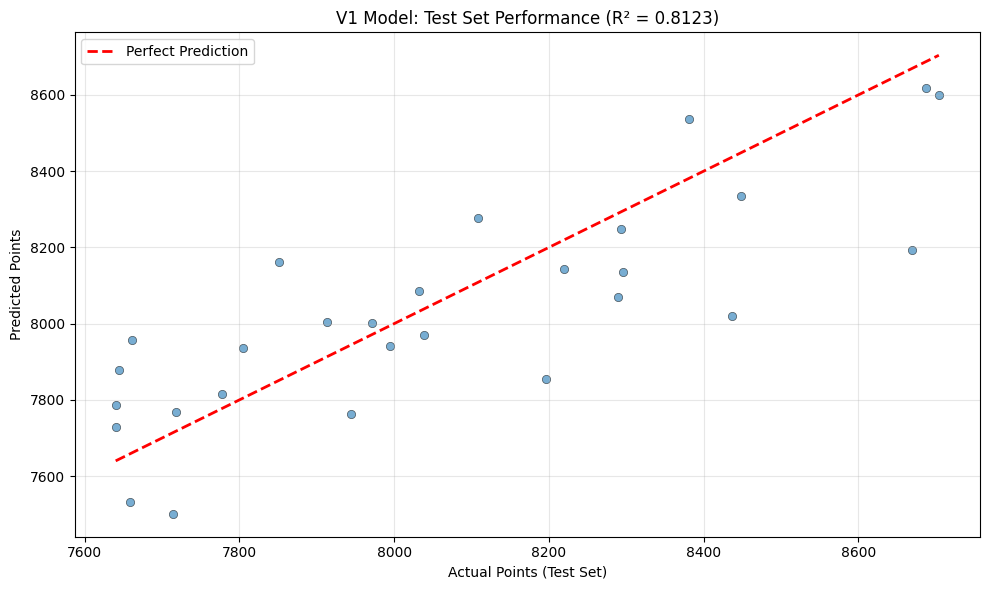

In [ ]:
print("=== V1 MODEL: PREDICTING POINTS ===\n")

v1_features = ['2PA', '3PA', 'FTA', 'AST', 'ORB', 'DRB', 'STL', 'BLK', 'TOV']

# Prepare training data
X_v1_train = df_work[v1_features].values
y_v1_train = df_work['PTS'].values

# Fit v1 model
PointsReg_v1 = LinearRegression()
PointsReg_v1.fit(X_v1_train, y_v1_train)

# Training predictions
y_v1_train_pred = PointsReg_v1.predict(X_v1_train)

# Training performance
r2_v1_train = r2_score(y_v1_train, y_v1_train_pred)
rmse_v1_train = np.sqrt(mean_squared_error(y_v1_train, y_v1_train_pred))

print("Training Set Performance:")
print(f"  R²: {r2_v1_train:.4f}")
print(f"  RMSE: {rmse_v1_train:.4f}")

# Coefficients
print(f"\nIntercept: {PointsReg_v1.intercept_:.4f}")
print("\nCoefficients:")
for feature, coef in zip(v1_features, PointsReg_v1.coef_):
    print(f"  {feature:>5}: {coef:>10.4f}")

# Test set evaluation
X_v1_test = NBA_test[v1_features].values
y_v1_test = NBA_test['PTS'].values

# Test predictions
y_v1_test_pred = PointsReg_v1.predict(X_v1_test)

# Test performance
SSE_v1 = np.sum((y_v1_test_pred - y_v1_test)**2)
SST_v1 = np.sum((df_work['PTS'].mean() - y_v1_test)**2)
r2_v1_test = 1 - SSE_v1/SST_v1
rmse_v1_test = np.sqrt(SSE_v1/len(NBA_test))

print("\nTest Set Performance:")
print(f"  R²: {r2_v1_test:.4f}")
print(f"  RMSE: {rmse_v1_test:.4f}")

# Summary comparison
print("\n=== V1 MODEL SUMMARY ===")
print(f"Features used: {len(v1_features)}")
print(f"Training R²: {r2_v1_train:.4f} | Test R²: {r2_v1_test:.4f}")
print(f"Training RMSE: {rmse_v1_train:.4f} | Test RMSE: {rmse_v1_test:.4f}")


# Visualization
plt.figure(figsize=(10, 6))
plt.scatter(y_v1_test, y_v1_test_pred, alpha=0.6, edgecolors='k', linewidth=0.5)
plt.plot([y_v1_test.min(), y_v1_test.max()], [y_v1_test.min(), y_v1_test.max()], 
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Points (Test Set)')
plt.ylabel('Predicted Points')
plt.title(f'V1 Model: Test Set Performance (R² = {r2_v1_test:.4f})')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()